In [1]:
%reload_ext autoreload
%autoreload 2

from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_coefficient_matrix,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    non_uniform_grid,
)

from config import ModelConfig
from buildoperators import TransportOperators
from membrane import MembraneReactorModel
from reaction import ReactionRates

In [2]:
cfg = ModelConfig()
build = TransportOperators(cfg)
model = MembraneReactorModel(cfg)
reaction = ReactionRates(cfg)

result = model.solve()



In [ ]:
# ── Post-processing ───────────────────────────────────────────────────
c_g, c_b, c_p, c_m = model.fields()
RT  = cfg.R * cfg.T
bar = 1e5

r1, r2 = reaction.reaction_rates(c_b[:, None, :], cfg)
P_bulk_bar = c_b * RT / bar  # (n_z, n_c)

# Adsorptieconstanten R1
K_CO2 = cfg.K_ads(cfg.K_CO2_ref, cfg.dH_CO2)
K_H2  = cfg.K_ads(cfg.K_H2_ref,  cfg.dH_H2)

# Inhibition R1
inh_1_inlet  = (1 + K_CO2*P_bulk_bar[0,  0] + np.sqrt(max(K_H2*P_bulk_bar[0,  1], 0)))**2
inh_1_outlet = (1 + K_CO2*P_bulk_bar[-1, 0] + np.sqrt(max(K_H2*P_bulk_bar[-1, 1], 0)))**2

# Thiele R1
c_surf_CO2 = np.maximum(c_p[:, -1, 0].mean(), 1e-30)
k_app_R1   = r1[:, 0].mean() / c_surf_CO2
phi_R1     = cfg.particle_radius * np.sqrt(k_app_R1 / cfg.D_eff)
eta_thiele = (3/phi_R1**2) * (phi_R1/np.tanh(phi_R1) - 1) if phi_R1 > 0.01 else 1.0

# Inhibition R2
inh_R2_inlet  = (1 + cfg.k_ads1*(P_bulk_bar[0,  2]/bar) 
                   + cfg.k_ads2*(P_bulk_bar[0,  2]/bar)*(P_bulk_bar[0,  0]/bar))
inh_R2_outlet = (1 + cfg.k_ads1*(P_bulk_bar[-1, 2]/bar) 
                   + cfg.k_ads2*(P_bulk_bar[-1, 2]/bar)*(P_bulk_bar[-1, 0]/bar))

# Alpha tellers
alpha1_inlet  = P_bulk_bar[0,  0]*P_bulk_bar[0,  1]**3 - P_bulk_bar[0,  2]*P_bulk_bar[0,  3]/cfg.k1_eq
alpha1_outlet = P_bulk_bar[-1, 0]*P_bulk_bar[-1, 1]**3 - P_bulk_bar[-1, 2]*P_bulk_bar[-1, 3]/cfg.k1_eq
alpha2_inlet  = (P_bulk_bar[0,  0]*bar)*(P_bulk_bar[0,  2]*bar)**2 - (P_bulk_bar[0,  4]*bar)*(P_bulk_bar[0,  3]*bar)/cfg.k2_eq
alpha2_outlet = (P_bulk_bar[-1, 0]*bar)*(P_bulk_bar[-1, 2]*bar)**2 - (P_bulk_bar[-1, 4]*bar)*(P_bulk_bar[-1, 3]*bar)/cfg.k2_eq

# Buizenbundel
V_buis   = np.pi * cfg.R_ret**2 * cfg.length
n_buizen = 1.0 / V_buis
tau      = cfg.length / cfg.v_ret
t_diff   = cfg.R_ret**2 / cfg.D_eff

# ── Prints ────────────────────────────────────────────────────────────
print(pd.Series({
    "reactor length [m]":        cfg.length,
    "R_ret [m]":                 cfg.R_ret,
    "v_ret [m/s]":               cfg.v_ret,
    "n_z [-]":                   cfg.n_z,
    "n_r_ret [-]":               cfg.n_r_ret,
    "T [K]":                     cfg.T,
    "p [Pa]":                    cfg.p,
    "eps_s [-]":                 cfg.eps_s,
    "eps_p [-]":                 cfg.eps_p,
    "rho_bulk [kg/m³]":          cfg.rho_bulk,
    "m_cat [kg]":                cfg.m_cat,
    "external area [1/m]":       cfg.external_area,
    "volume per buis [m³]":      V_buis,
    "aantal buizen voor 1 m³":   n_buizen,
    "  term CO2 inlet":  K_CO2 * P_bulk_bar[0,  0],
    "  term H2  inlet":  np.sqrt(max(K_H2 * P_bulk_bar[0,  1], 0)),
    "  term CO2 outlet": K_CO2 * P_bulk_bar[-1, 0],
    "  term H2  outlet": np.sqrt(max(K_H2 * P_bulk_bar[-1, 1], 0)),
}, name="reactor config"))

print(pd.Series({
    "success":                   result.success,
    "Newton iterations":         result.nit,
    "residual norm (inf)":       np.linalg.norm(result.fun, ord=np.inf),
    "τ verblijftijd [s]":        tau,
    "Pe_ax [-]":                 cfg.v_ret * cfg.length / cfg.d_ax,
    "Pe_rad [-]":                cfg.v_ret * cfg.R_ret  / cfg.D_eff,
    "t_diff [s]":                t_diff,
    "φ Thiele R1 [-]":           phi_R1,
    "η analytisch R1 [-]":       eta_thiele,
}, name="solver & diagnostics"))

print(pd.Series({
    "outlet CO2 conversion [-]":          1.0 - c_g[-1, 0] / c_g[0, 0],
    "outlet H2  conversion [-]":          1.0 - c_g[-1, 1] / c_g[0, 1],
    "outlet CH3OH [mol/m³]":              c_g[-1, 2],
    "outlet H2O permeate [mol/m³]":       c_m[-1, 3],
    "outlet DMC [mol/m³]":                c_g[-1, 4],
}, name="conversie & producten"))

print(pd.Series({
    "k_eff R1 [mol/s/bar²/kg]":           cfg.k_eff_r1(),
    "k_eff R2 [s⁻¹]":                     cfg.k_eff_r2(cfg.p),
    "r1 inlet  [mol/m³/s]":               r1[0,  0],
    "r1 outlet [mol/m³/s]":               r1[-1, 0],
    "alpha_1 inlet  [bar⁴]":                   alpha1_inlet,
    "alpha_1 outlet [bar⁴]":                   alpha1_outlet,
    "inhibition R1 inlet  [-]":            inh_1_inlet,
    "inhibition R1 outlet [-]":            inh_1_outlet,
    "  term CO2 inlet":                    K_CO2 * P_bulk_bar[0,  0],
    "  term H2  inlet":                    np.sqrt(max(K_H2 * P_bulk_bar[0,  1], 0)),
    "  term CO2 outlet":                   K_CO2 * P_bulk_bar[-1, 0],
    "  term H2  outlet":                   np.sqrt(max(K_H2 * P_bulk_bar[-1, 1], 0)),
}, name="R1 kinetiek"))

print(pd.Series({
    "r2 inlet  [mol/m³/s]":                r2[0,  0],
    "r2 outlet [mol/m³/s]":                r2[-1, 0],
    "alpha_2 inlet":                       alpha2_inlet,
    "alpha_2 outlet":                      alpha2_outlet,
    "inhibition R2 inlet  [-]":            inh_R2_inlet,
    "inhibition R2 outlet [-]":            inh_R2_outlet,
    "P_CH3OH inlet [bar]":                 P_bulk_bar[0,  2],
    "P_CH3OH outlet [bar]":                P_bulk_bar[-1, 2],
}, name="R2 kinetiek"))

reactor length [m]         5.000000e+00
R_ret [m]                  1.000000e-02
v_ret [m/s]                1.000000e-01
n_z [-]                    1.000000e+02
n_r_ret [-]                3.000000e+01
T [K]                      4.000000e+02
p [Pa]                     3.000000e+06
eps_s [-]                  4.000000e-01
eps_p [-]                  5.000000e-01
rho_bulk [kg/m³]           1.443000e+03
m_cat [kg]                 2.266659e+00
external area [1/m]        1.200000e+03
volume per buis [m³]       1.570796e-03
aantal buizen voor 1 m³    6.366198e+02
  term CO2 inlet           2.238456e+00
  term H2  inlet           4.671627e+00
  term CO2 outlet          1.216769e+00
  term H2  outlet          3.461698e+00
Name: reactor config, dtype: float64
success                    True
Newton iterations             6
residual norm (inf)    0.000123
τ verblijftijd [s]         50.0
Pe_ax [-]               25000.0
Pe_rad [-]                100.0
t_diff [s]                 10.0
φ Thiele R1 [-]    

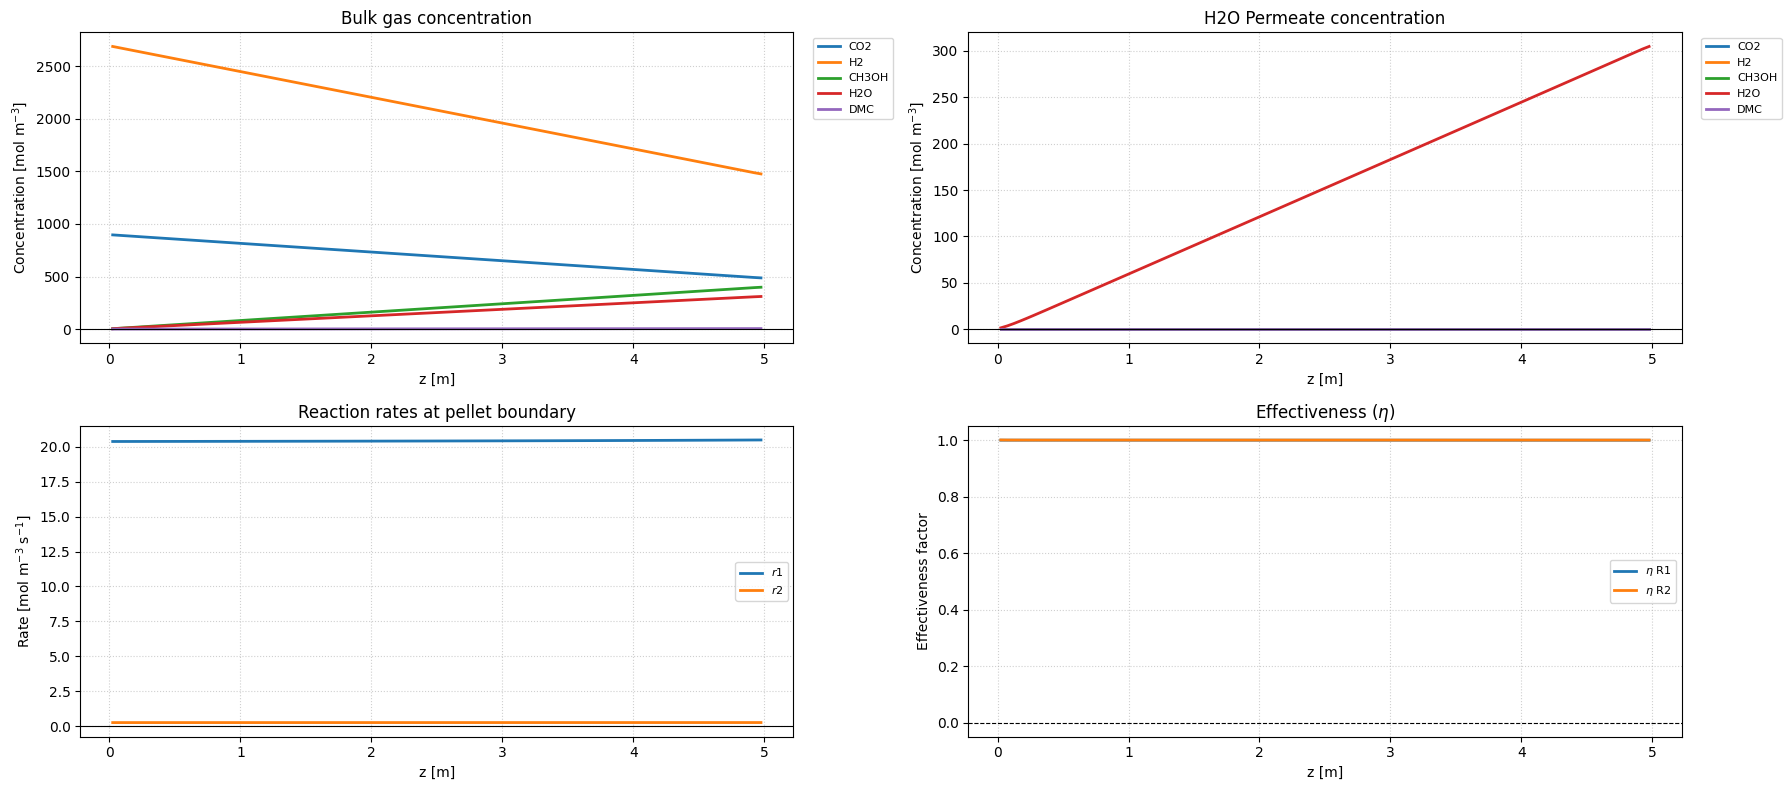

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False)
axes = axes.flatten()
 
# axes[0]: Bulk Gas Concentration
for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label, linewidth=2)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)
 
# axes[1]: H2O Permeate Concentration
for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label, linewidth=2)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel(r"Concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1, fontsize=8, frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)
 
# axes[2]: Reaction Rates
axes[2].plot(model.z_c, r1, label=r"$r1$", linewidth=2)
axes[2].plot(model.z_c, r2, label=r"$r2$", linewidth=2)
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate [mol m$^{-3}$ s$^{-1}$]")
axes[2].set_title("Reaction rates at pellet boundary")
axes[2].legend(loc="best", fontsize=8)
axes[2].grid(True, linestyle=":", alpha=0.6)
 
# axes[3]: Effectiveness Profile
eta_r1, eta_r2, _, _ = model.effectiveness_profile()
axes[3].plot(model.z_c, eta_r1, label=r"$\eta$ R1", linewidth=2)
axes[3].plot(model.z_c, eta_r2, label=r"$\eta$ R2", linewidth=2)
axes[3].axhline(0.0, color="k", linewidth=0.8, linestyle="--")
axes[3].set_xlabel("z [m]")
axes[3].set_ylabel("Effectiveness factor")
axes[3].set_title(r"Effectiveness ($\eta$)")
axes[3].grid(True, linestyle=":", alpha=0.6)
axes[3].legend(loc="best", fontsize=8)
 
plt.tight_layout()
plt.show()